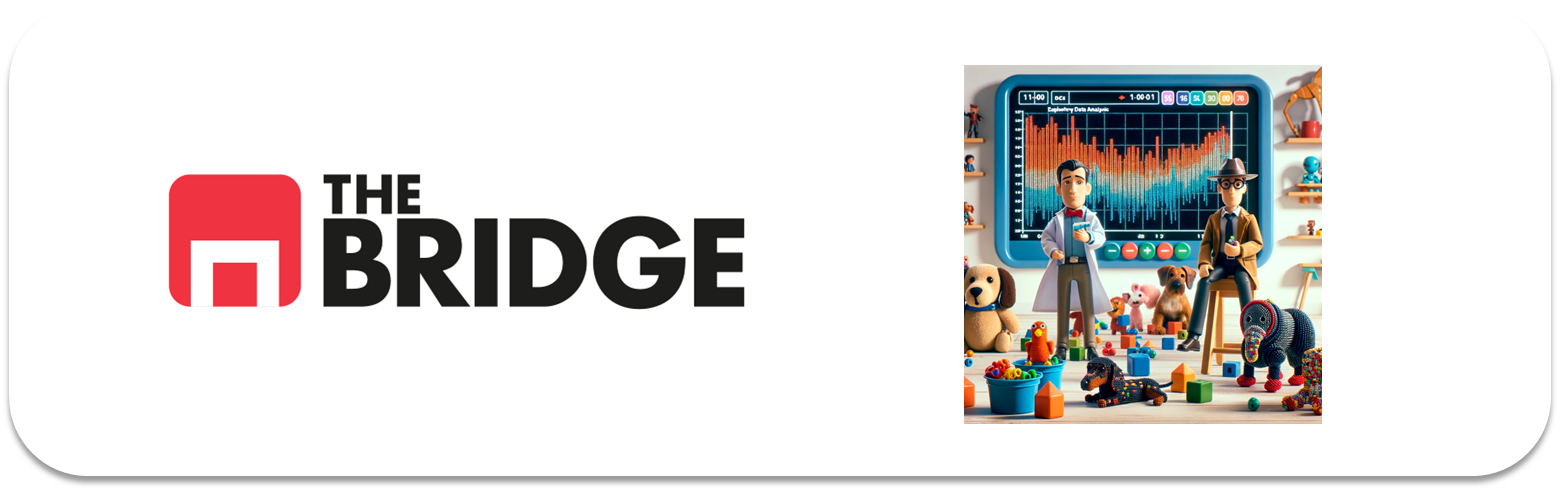

## PRACTICA OBLIGATORIA: **Análisis Multivariante**

* La práctica obligatoria de esta unidad consiste en completar el análisis del dataset del Titanic, dirigido por una serie de preguntas, y de terminar de analizar algunos aspectos del dataset de viajes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0


Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, mannwhitneyu  # tests habituales

# Opcional: calidad de gráficos
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

## #1: Titanic

### #1.1

Carga en un dataframe el dataset del titanic, que está en la ruta "./data/titanic.csv".

In [2]:
import pandas as pd

df = pd.read_csv("./data/titanic.csv")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### #1.2

Deshazte de las columnas "deck", "survived", "pclass" y "embarked" porque no las emplearemos, la primera por su cantidad de nulos y el resto porque son variantes de otras que ya existen y cuyos valores resultan más expresivos a la hora de hacer un análisis. 

In [3]:
# Eliminar columnas redundantes / poco informativas
df.drop(columns=["deck", "survived", "pclass", "embarked"], inplace=True)

# Comprobar
df.head()

,sex,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone
0,male,22.0,1,0,7.2500,Third,man,True,Southampton,no,False
1,female,38.0,1,0,71.2833,First,woman,False,Cherbourg,yes,False
2,female,26.0,0,0,7.9250,Third,woman,False,Southampton,yes,True
3,female,35.0,1,0,53.1000,First,woman,False,Southampton,yes,False
4,male,35.0,0,0,8.0500,Third,man,True,Southampton,no,True


### #1.3

Suma las columnas "parch" y "sibsp" para tener el número de parientes de cada pasajero, guarda el resultado en otra columna "family_members", luego deshazte de "parch" y "sibsp"

In [4]:
# Crear la nueva columna con el total de familiares a bordo
df["family_members"] = df["parch"] + df["sibsp"]

# Eliminar las columnas originales
df.drop(columns=["parch", "sibsp"], inplace=True)

df.head()

,sex,age,fare,class,who,adult_male,embark_town,alive,alone,family_members
0,male,22.0,7.2500,Third,man,True,Southampton,no,False,1
1,female,38.0,71.2833,First,woman,False,Cherbourg,yes,False,1
2,female,26.0,7.9250,Third,woman,False,Southampton,yes,True,0
3,female,35.0,53.1000,First,woman,False,Southampton,yes,False,1
4,male,35.0,8.0500,Third,man,True,Southampton,no,True,0


### #1.4

Imputa la moda a los valores nulos de "embark_town"

In [5]:
moda_embark = df["embark_town"].mode()[0]
df["embark_town"] = df["embark_town"].fillna(moda_embark)

In [6]:
df["embark_town"].isna().sum()

np.int64(0)

### #1.5

Imputa la media a los valores faltantes de "age", si quieres puedes hacer algo más preciso (por ejemplo considerando además la columna "who")

In [7]:
df["age"] = df["age"].fillna(df.groupby("who")["age"].transform("mean"))

In [8]:
df["age"].isna().sum()

np.int64(0)

### #1.6

Realiza los análisis bivariantes o multivariantes que necesites, así como los test de hipótesis necesarios para contestar a las siguientes preguntas. Nota: utiliza la variable "alive" para saber si un pasajero sobrevivió o no:

1. En términos absolutos, ¿sobrevivieron más hombres, mujeres o niños? ¿Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre el sexo y la supervivencia en el Titanic?¿Y entre ser adulto o ser niño?

2. En términos absolutos, ¿de que clase sobrevivieron más pasajeros?¿ Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre la clase en la que se viajaba y la supervivencia?

3. ¿De qué ciudad sobrevivieron más personas?¿Y porcentualmente de que ciudad sobrevivieron más personas? ¿Hay alguna relación estadística significativa entre haber embarcado en una de las tres ciudades y haber sobrevivido o fallecido?

4. ¿Qué relación hay entre el precio del pasaje y la supervivencia/fallecimiento?

5. Existen pasajero que no pagaron el billete, ¿podrías explicar por qué? ¿Qué ocurrió con la persona que más dinero se dejó?

6. Existe alguna relación entre el dinero pagado, la ciudad de embarque y la superviviencia/fallecimiento. No necesitas aplicar ningún test, muestralo numérica o visualmente.

7. Ahondando en la relación entre sobrevivir o fallecer, la clase en la que se viajó y la edad de los pasajeros. ¿Qué agrupación de las dos variables (clase y edad) sobrevivió más en términos absolutos y en términos relativos?

8. Finalmente, muestra las posibles relaciones entre edad, coste del billete y supervivencia/fallecimiento. ¿Qué puedes decir al respecto?

alive,no,yes
sex,,
female,81,233
male,468,109


alive,no,yes
sex,,
female,25.80,74.20
male,81.11,18.89


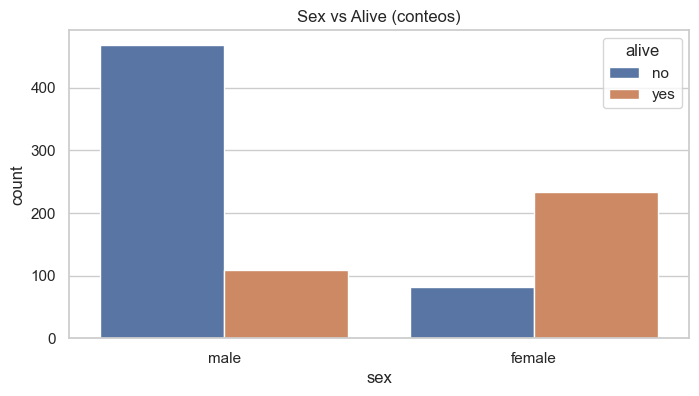

(np.float64(260.71702016732104), np.float64(1.1973570627755645e-58))

In [9]:
#1

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Sexo vs supervivencia
ct_sex = pd.crosstab(df["sex"], df["alive"])
display(ct_sex)
display((ct_sex.div(ct_sex.sum(axis=1), axis=0)*100).round(2))  # % por fila

sns.countplot(data=df, x="sex", hue="alive")
plt.title("Sex vs Alive (conteos)")
plt.show()

chi2, p, dof, exp = chi2_contingency(ct_sex)
chi2, p

En términos absolutos: sobrevivieron más mujeres (233) que hombres (109).

En términos relativos: mujeres ~74% sobreviven vs hombres ~19%.

Sí hay relación significativa (p ≈ 1.2e-58).

In [10]:
#Adulto vs niño (usando who):

df["adult_or_child"] = np.where(df["who"]=="child", "child", "adult")
ct_ac = pd.crosstab(df["adult_or_child"], df["alive"])
display(ct_ac)
display((ct_ac.div(ct_ac.sum(axis=1), axis=0)*100).round(2))

chi2, p, *_ = chi2_contingency(ct_ac)
chi2, p


alive,no,yes
adult_or_child,,
adult,515,293
child,34,49


alive,no,yes
adult_or_child,,
adult,63.74,36.26
child,40.96,59.04


(np.float64(15.556993340077092), np.float64(8.005497211300105e-05))

Niños: 49 sobreviven / 34 fallecen → ~59% supervivencia

Adultos: 293 sobreviven / 515 fallecen → ~36% supervivencia

También es significativo (p ≈ 8.0e-05).

alive,no,yes
class,,
First,80,136
Second,97,87
Third,372,119


alive,no,yes
class,,
First,37.04,62.96
Second,52.72,47.28
Third,75.76,24.24


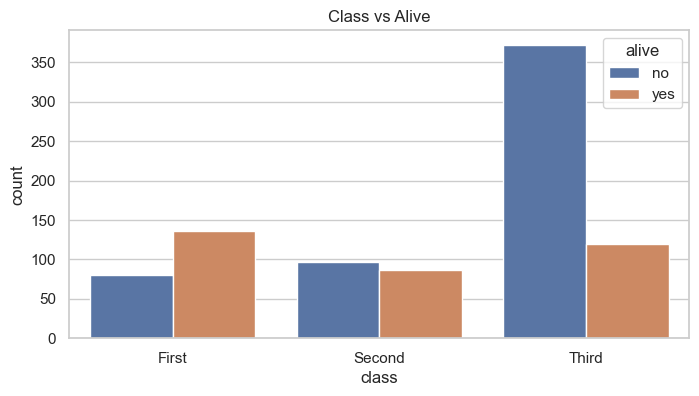

(np.float64(102.88898875696056), np.float64(4.549251711298793e-23))

In [11]:
#2

ct_class = pd.crosstab(df["class"], df["alive"])
display(ct_class)
display((ct_class.div(ct_class.sum(axis=1), axis=0)*100).round(2))

sns.countplot(data=df, x="class", hue="alive", order=["First","Second","Third"])
plt.title("Class vs Alive")
plt.show()

chi2, p, *_ = chi2_contingency(ct_class)
chi2, p

En absoluto, sobreviven más de First (136), luego Third (119), luego Second (87).

En relativo: First ~63%, Second ~47%, Third ~24%.

Sí hay relación significativa (p ≈ 4.55e-23).

alive,no,yes
embark_town,,
Cherbourg,75,93
Queenstown,47,30
Southampton,427,219


alive,no,yes
embark_town,,
Cherbourg,44.64,55.36
Queenstown,61.04,38.96
Southampton,66.10,33.90


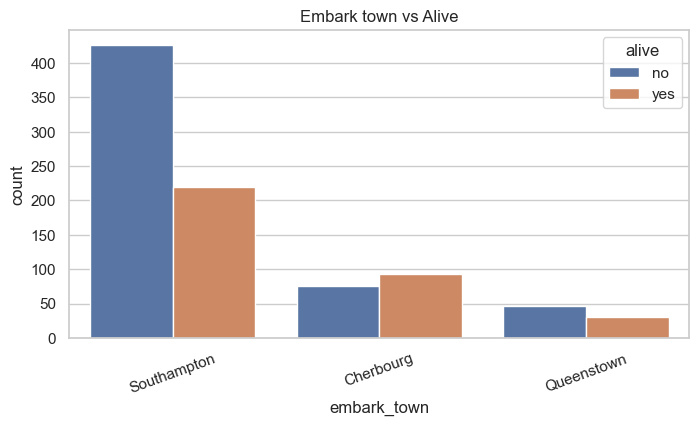

(np.float64(25.964452881874784), np.float64(2.3008626481449577e-06))

In [12]:
#3

ct_town = pd.crosstab(df["embark_town"], df["alive"])
display(ct_town)
display((ct_town.div(ct_town.sum(axis=1), axis=0)*100).round(2))

sns.countplot(data=df, x="embark_town", hue="alive")
plt.title("Embark town vs Alive")
plt.xticks(rotation=20)
plt.show()

chi2, p, *_ = chi2_contingency(ct_town)
chi2, p

En absoluto sobreviven más de Southampton (219) (porque es el grupo más grande).

En porcentajes: Cherbourg ~55%, Queenstown ~39%, Southampton ~34%.

Sí hay relación significativa (p ≈ 2.30e-06).

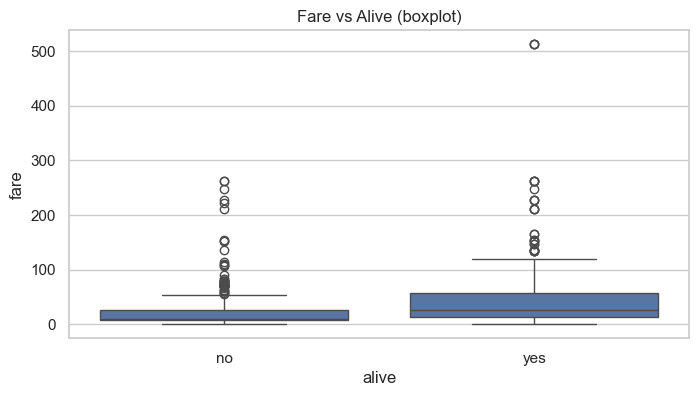

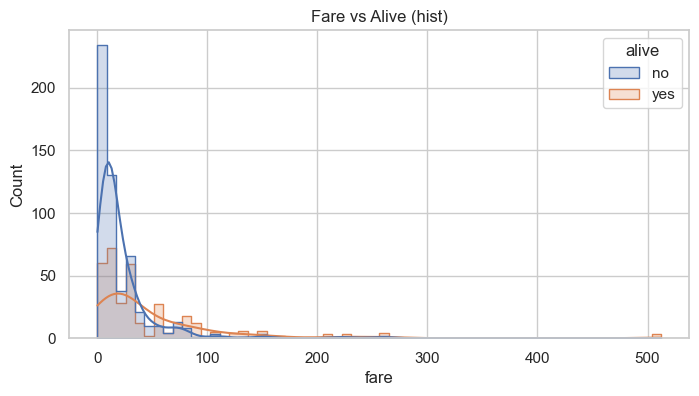

In [13]:
#4

df.groupby("alive")["fare"].describe()

sns.boxplot(data=df, x="alive", y="fare")
plt.title("Fare vs Alive (boxplot)")
plt.show()

sns.histplot(data=df, x="fare", hue="alive", kde=True, element="step")
plt.title("Fare vs Alive (hist)")
plt.show()

Media fare yes ~48.4 vs no ~22.1 → sobreviven más los que pagan más (asociación fuerte).

Hay muchos outliers (tarifas altísimas, 1ª clase).

In [14]:
#5

df_zero = df[df["fare"]==0]
df_zero[["sex","age","class","embark_town","alive","alone","family_members"]].head(15), df_zero.shape

(      sex        age   class  embark_town alive  alone  family_members
 179  male  36.000000   Third  Southampton    no   True               0
 263  male  40.000000   First  Southampton    no   True               0
 271  male  25.000000   Third  Southampton   yes   True               0
 277  male  33.173123  Second  Southampton    no   True               0
 302  male  19.000000   Third  Southampton    no   True               0
 413  male  33.173123  Second  Southampton    no   True               0
 466  male  33.173123  Second  Southampton    no   True               0
 481  male  33.173123  Second  Southampton    no   True               0
 597  male  49.000000   Third  Southampton    no   True               0
 633  male  33.173123   First  Southampton    no   True               0
 674  male  33.173123  Second  Southampton    no   True               0
 732  male  33.173123  Second  Southampton    no   True               0
 806  male  39.000000   First  Southampton    no   True         

Probables motivos: billete pagado por tercero / billete grupal, registros incompletos, o pasaje “no estándar”.

En tu CSV: 14 de 15 con fare=0 fallecen (dato llamativo).

In [16]:
#Persona(s) con máxima tarifa:

max_fare = df["fare"].max()
df[df["fare"]==max_fare][["sex","age","class","embark_town","alive","alone","family_members"]]

,sex,age,class,embark_town,alive,alone,family_members
258,female,35.0,First,Cherbourg,yes,True,0
679,male,36.0,First,Cherbourg,yes,False,1
737,male,35.0,First,Cherbourg,yes,True,0


La tarifa máxima es 512.3292 y aparece en 3 pasajeros: los 3 sobreviven (First, Cherbourg).
(Que se repita suele indicar mismo ticket / mismo precio registrado para varios pasajeros.)

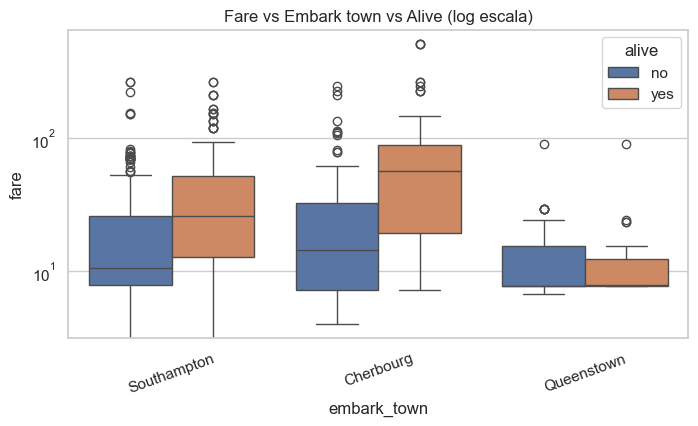

In [17]:
#6

df.groupby(["embark_town","alive"])["fare"].agg(["count","mean","median"]).round(2)

sns.boxplot(data=df, x="embark_town", y="fare", hue="alive")
plt.yscale("log")  # importante por asimetría de fare
plt.title("Fare vs Embark town vs Alive (log escala)")
plt.xticks(rotation=20)
plt.show()

Cherbourg concentra tarifas más altas, y mayor % de supervivencia.

Queenstown tarifas bajas casi siempre (sobrevivas o no).

alive           no  yes
class  sex             
First  female    3   91
       male     77   45
Second female    6   70
       male     91   17
Third  female   72   72
       male    300   47

alive             no    yes
class  sex                 
First  female   3.19  96.81
       male    63.11  36.89
Second female   7.89  92.11
       male    84.26  15.74
Third  female  50.00  50.00
       male    86.46  13.54

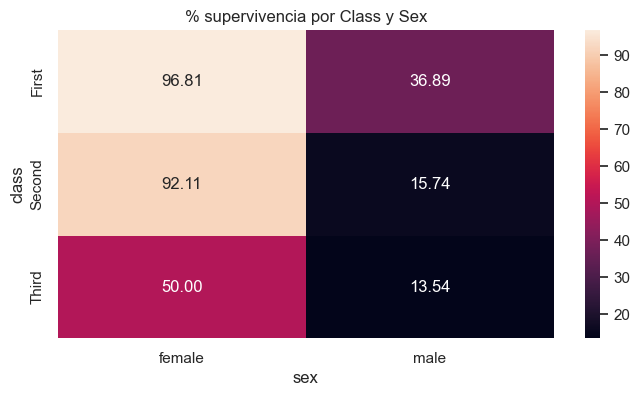

In [19]:
#7

ct = pd.crosstab([df["class"], df["sex"]], df["alive"])
display(ct)

rate = (ct.div(ct.sum(axis=1), axis=0)*100).round(2)
display(rate)

# Heatmap de supervivencia (% yes)
heat = rate["yes"].unstack()
sns.heatmap(heat, annot=True, fmt=".2f")
plt.title("% supervivencia por Class y Sex")
plt.show()

Más supervivientes en absoluto: mujeres de 1ª (91).

Mayor supervivencia relativa: mujeres de 1ª (~96.8%) y mujeres de 2ª (~92.1%).

Peor grupo: hombres de 3ª (~13.5%).

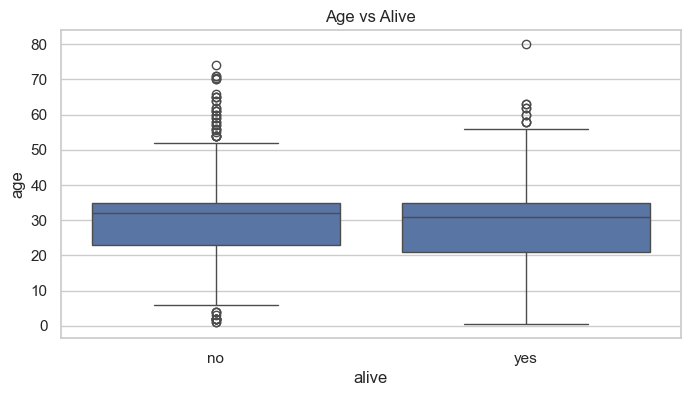

In [20]:
#8

#Edad vs supervivencia

df.groupby("alive")["age"].describe()

sns.boxplot(data=df, x="alive", y="age")
plt.title("Age vs Alive")
plt.show()

alive,no,yes
family_members,,
0,374,163
1,72,89
2,43,59
3,8,21
4,12,3
5,19,3
6,8,4
7,6,0
10,7,0


alive,no,yes
family_members,,
0,69.65,30.35
1,44.72,55.28
2,42.16,57.84
3,27.59,72.41
4,80.00,20.00
5,86.36,13.64
6,66.67,33.33
7,100.00,0.00
10,100.00,0.00


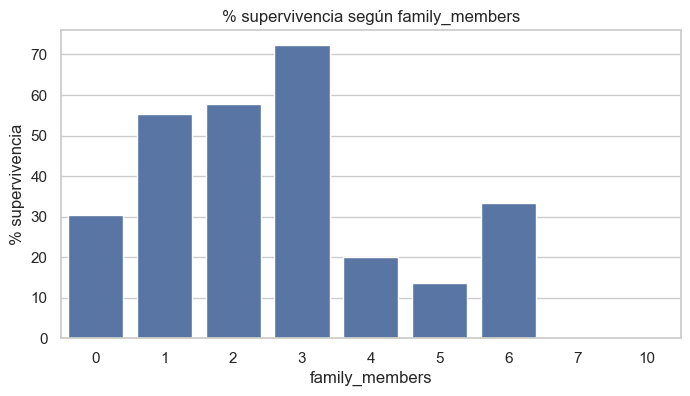

In [21]:
#Familia (family_members) vs supervivencia

ct_fam = pd.crosstab(df["family_members"], df["alive"])
display(ct_fam)
display((ct_fam.div(ct_fam.sum(axis=1), axis=0)*100).round(2))

sns.barplot(x=ct_fam.index, y=(ct_fam["yes"]/ct_fam.sum(axis=1))*100)
plt.title("% supervivencia según family_members")
plt.ylabel("% supervivencia")
plt.show()

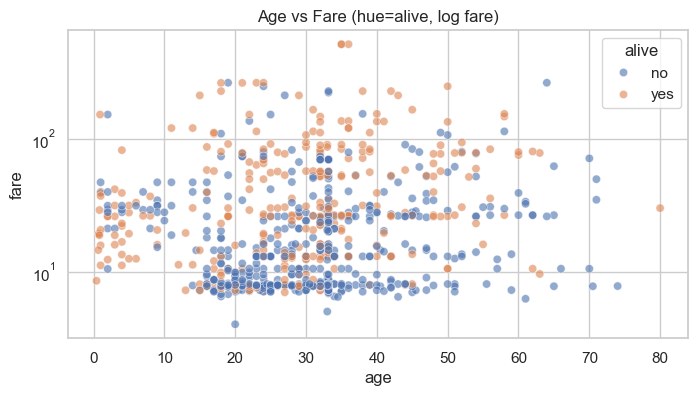

In [22]:
#Scatter multivariante (edad vs dinero, coloreado por supervivencia)

sns.scatterplot(data=df, x="age", y="fare", hue="alive", alpha=0.6)
plt.yscale("log")
plt.title("Age vs Fare (hue=alive, log fare)")
plt.show()

Survivors tienden a pagar más fare (muy marcado).

age muestra diferencia menor (sobrevivientes algo más jóvenes).

Viajar con poca familia (1–3) suele asociarse a mejor supervivencia que ir solo o con familia muy grande (aunque en familias grandes hay pocos casos).

#1.6 — Conclusiones finales (Análisis bivariante / multivariante)

1) Supervivencia según sexo y según ser adulto/niño
En términos absolutos, sobrevivieron más mujeres (233) que hombres (109). En términos relativos la diferencia es enorme: aprox. 74% de mujeres sobreviven frente a ~19% de hombres, lo que encaja con la política de evacuación de “mujeres y niños primero”. La relación entre sexo y supervivencia es estadísticamente significativa (Chi-cuadrado, p ≪ 0.05).
Además, comparando adultos vs niños, los niños sobreviven más proporcionalmente (~59%) que los adultos (~36%), y también se observa una relación significativa (p ≪ 0.05).

2) Supervivencia según clase
En términos absolutos, el mayor número de supervivientes se observa en First class (136), seguido de Third (119) y Second (87). Sin embargo, lo más relevante es el porcentaje: First ~63% de supervivencia, Second ~47%, Third ~24%. Esto sugiere que viajar en una clase más alta aumentaba notablemente las probabilidades de sobrevivir. La relación clase–supervivencia es significativa (Chi-cuadrado, p ≪ 0.05).

3) Supervivencia según ciudad de embarque
En valor absoluto, Southampton aporta más supervivientes (219) porque es el grupo más grande. No obstante, en términos relativos, Cherbourg presenta el mejor porcentaje de supervivencia (~55%), seguido de Queenstown (~39%) y Southampton (~34%). Existe también relación significativa entre el puerto de embarque y la supervivencia (p ≪ 0.05), lo que probablemente está mediado por la clase social y el precio del billete.

4) Precio del billete (fare) y supervivencia
Se observa una relación clara: los pasajeros que sobreviven tienen un fare promedio mayor (media ~48) que los que fallecen (media ~22). La distribución del precio está muy sesgada a la derecha, con muchos valores bajos y algunos extremadamente altos, pero aun así el patrón general indica que pagar más se asocia con mayor probabilidad de supervivencia.

5) Pasajeros con fare = 0 y caso del máximo fare
Existen 15 pasajeros con fare = 0. Esto puede deberse a billetes pagados por terceros, billetes colectivos, condiciones especiales (tripulación o acuerdos) o registros incompletos. En el dataset, 14 de esos 15 fallecen, lo cual es coherente con un perfil generalmente desfavorable (posible tercera clase o peores condiciones).
El valor máximo de fare es 512.3292 y aparece en tres pasajeros, que además sobreviven los tres, reforzando la idea de que un billete muy caro (asociado a primera clase) incrementaba las opciones de supervivencia.

6) Relación entre dinero pagado, ciudad de embarque y supervivencia
Visual y numéricamente se aprecia que Cherbourg concentra billetes más caros y, a la vez, un mayor porcentaje de supervivencia. Por el contrario, Queenstown presenta tarifas generalmente bajas y porcentajes de supervivencia menores. Esto sugiere que el puerto de embarque está relacionado indirectamente con la supervivencia porque está asociado a perfiles socioeconómicos distintos reflejados en fare y class.

7) Supervivencia combinando clase y sexo
Al cruzar clase y sexo, el patrón es muy contundente: el grupo con mejor supervivencia relativa es el de mujeres en First (~96.8%) y mujeres en Second (~92.1%). En cambio, el peor grupo es el de hombres en Third (~13.5%). En términos absolutos, destacan las mujeres de First como el grupo con más supervivientes. Esto confirma que la supervivencia dependió fuertemente de una combinación de género y estatus (clase).

8) Relaciones entre edad, coste, familia a bordo y supervivencia
La variable age muestra una diferencia más moderada: los supervivientes son, de media, ligeramente más jóvenes, aunque la diferencia no es tan fuerte como con fare o class. El precio del billete (fare) sigue siendo uno de los mejores indicadores de supervivencia y actúa como proxy de clase/estatus.
Respecto a family_members, se observa que viajar con poca familia (1–3) tiende a asociarse con mejores tasas de supervivencia que viajar solo o con familias muy numerosas, donde los casos son pocos pero la supervivencia suele caer. En conjunto, el patrón global sugiere que clase/estatus (fare + class) y sexo explican gran parte de la supervivencia, mientras que edad y familia aportan matices adicionales.